# Moving Beyond Linearity
So far we model only linear relationship between predictors X and response Y. This allows to derive insights on the relationship between X and Y and infer information from the statistics rather easy but on the other hand makes fitting f hard as some relationships are non linear. We investigating generalized linear models and how to deal with exponential distributions by using the link function to make non linear data linear. In this notebook we move on to non linear models focusing on 
1. Polynomial Regression
2. Step functions
3. Regression splines
4. Smoothing splines
5. Local regression
6. Generalized additive models (GAMs)

## Polynomial regression
So far we always modeled lineare regression in the following way

$$
Y = \beta_0 + \beta_1 X_1^1 + ... + \beta_n X_n^1

$$

now we extend this to use higher order terms 

$$
Y = \beta_0 + \beta_1 X_1^1 + \beta_2 X_1^2... + \beta_n X_1^n

$$

This allows us to describe higher order relation ships between predictor and response. To fit the model coefficients we use least squares similar to linear regression. In praxis its uncommon to use degrees higher 3 or 4 as they tend to become over flexible outside of the train dataset region X and the polynomials extrapolate X taken into account the global shape of X. 

We can calculate the variance as well as the covariance of the fitted parameters $\beta$ and estimate therefor the 95% confidence interval using the parameters which are on this outer interval.

## Polynomial Standard Error Formula as generalization from linear regression

### 1. Simple Linear Regression (Scalar Form)

We start with the simple linear regression model

$$
Y = \beta_0 + \beta_1 x + \varepsilon,
\qquad \varepsilon \sim \mathcal N(0, \sigma^2)
$$

The fitted value at a point $x_0$ is

$$
\hat y(x_0) = \hat\beta_0 + \hat\beta_1 x_0
$$

From classical regression theory (ISL, Section 3.1), the variance of the fitted value is

$$
\mathrm{Var}(\hat y(x_0))
=
\hat\sigma^2
\left[
\frac{1}{n}
+
\frac{(x_0 - \bar x)^2}{\sum_{i=1}^n (x_i - \bar x)^2}
\right]
$$

This expression explains why uncertainty increases as $x_0$ moves away from the center of the data.

---

### 2. Simple Linear Regression (Matrix Form)

Define the design matrix

$$
\mathbf X =
\begin{pmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{pmatrix},
\qquad
\boldsymbol\beta =
\begin{pmatrix}
\beta_0 \\
\beta_1
\end{pmatrix}
$$

The model can be written compactly as

$$
\mathbf y = \mathbf X \boldsymbol\beta + \boldsymbol\varepsilon
$$

The least squares estimator is

$$
\hat{\boldsymbol\beta}
=
(\mathbf X^\top \mathbf X)^{-1} \mathbf X^\top \mathbf y
$$

Its covariance matrix is

$$
\mathrm{Var}(\hat{\boldsymbol\beta})
=
\sigma^2 (\mathbf X^\top \mathbf X)^{-1}
$$

---

### 3. Variance of the Fitted Value (General Formula)

For any input $x_0$, define its feature vector

$$
\mathbf x_0 =
\begin{pmatrix}
1 \\
x_0
\end{pmatrix}
$$

The fitted value is

$$
\hat y(x_0) = \mathbf x_0^\top \hat{\boldsymbol\beta}
$$

Using linearity of variance,

$$
\mathrm{Var}(\hat y(x_0))
=
\mathbf x_0^\top
\mathrm{Var}(\hat{\boldsymbol\beta})
\mathbf x_0
=
\sigma^2
\mathbf x_0^\top
(\mathbf X^\top \mathbf X)^{-1}
\mathbf x_0
$$

This expression is **exactly equivalent** to the scalar formula in simple linear regression.

---

### 4. Polynomial Regression

A polynomial regression model of degree $d$ is

$$
Y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d + \varepsilon
$$

Define the design matrix

$$
\mathbf X =
\begin{pmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^d \\
1 & x_2 & x_2^2 & \cdots & x_2^d \\
\vdots & \vdots & \vdots & & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^d
\end{pmatrix}
$$

The model is still

$$
\mathbf y = \mathbf X \boldsymbol\beta + \boldsymbol\varepsilon
$$

Thus, **polynomial regression is just linear regression with a different design matrix**.

---

### 5. Variance of the Polynomial Fit

For a point $x_0$, define

$$
\mathbf x_0 =
\begin{pmatrix}
1 & x_0 & x_0^2 & \cdots & x_0^d
\end{pmatrix}^\top
$$

The variance of the fitted value is

$$
\mathrm{Var}(\hat y(x_0))
=
\sigma^2
\mathbf x_0^\top
(\mathbf X^\top \mathbf X)^{-1}
\mathbf x_0
$$

Since $\sigma^2$ is unknown, we estimate it by

$$
\hat\sigma^2
=
\frac{1}{n - (d+1)}
\sum_{i=1}^n (y_i - \hat y_i)^2
$$

---

### 6. Connection to the Code

The quantity

$$
\mathbf X (\mathbf X^\top \mathbf X)^{-1} \mathbf X^\top
$$

is the **hat matrix** $\mathbf H$. Its diagonal entries satisfy

$$
\mathrm{Var}(\hat y_i) = \hat\sigma^2 H_{ii}
$$

This is exactly what is computed in the function:

```python
np.sqrt(np.diag(X_design @ XtX_inv @ X_design.T) * residual_var)


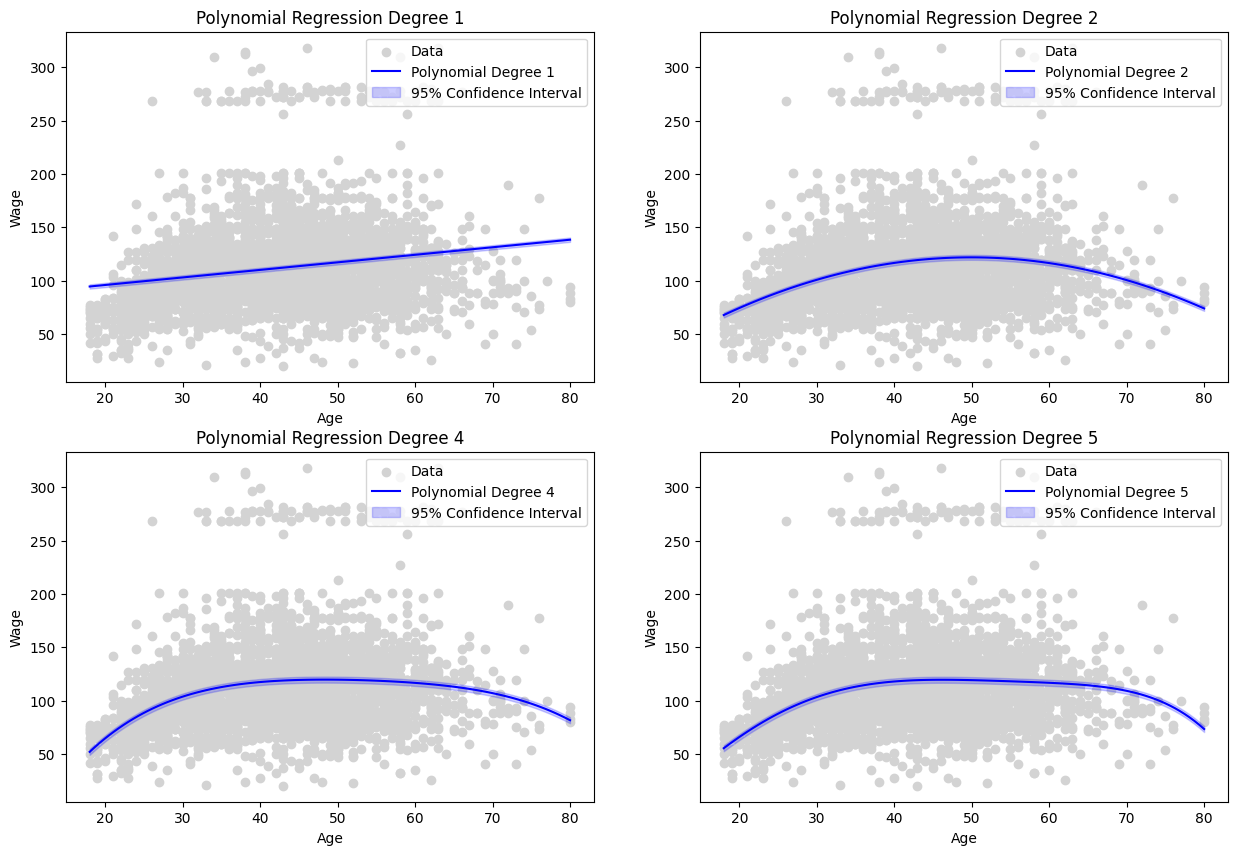

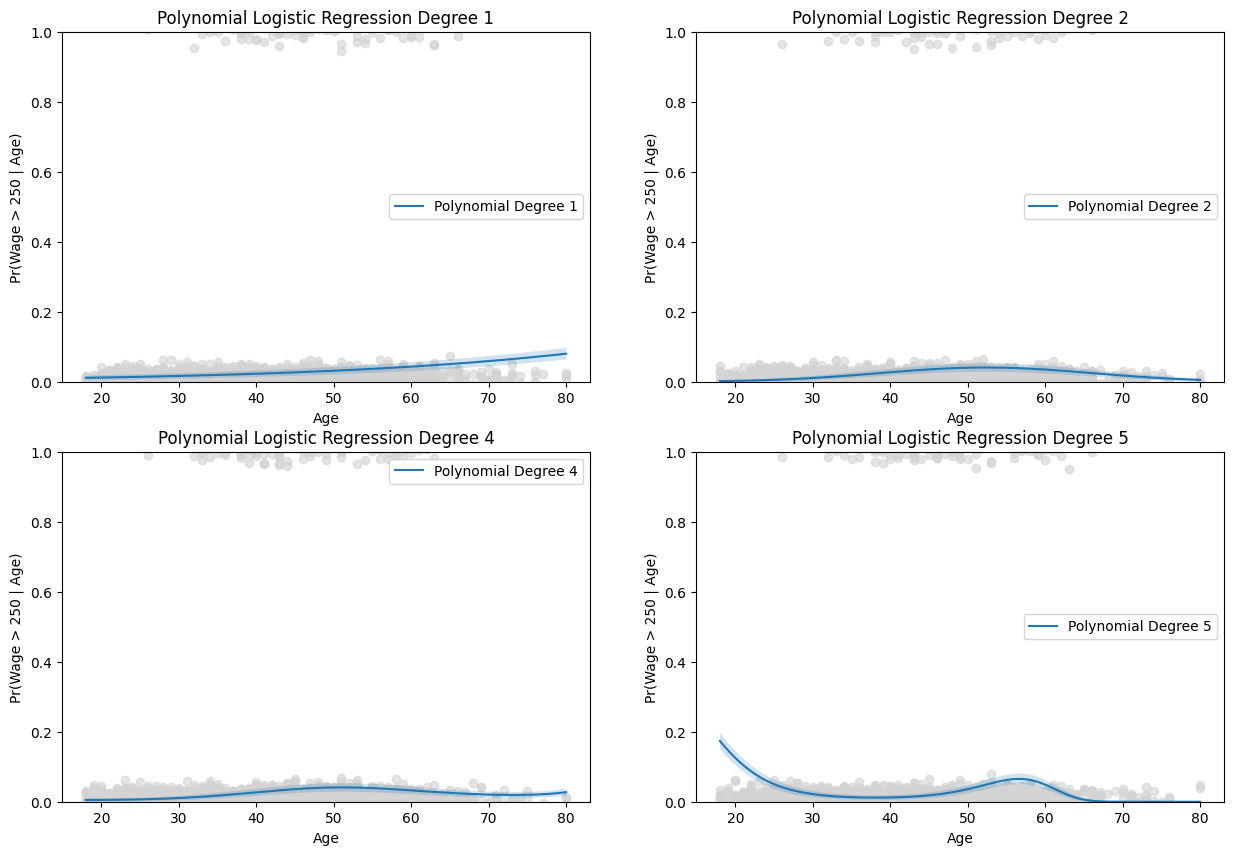

In [109]:
## Example Polynomial Fit

# Load the Income dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

data = pd.read_csv('data/Wage.csv')
X = data['age'].values
y = data['wage'].values

# Fit polynomial regression models of degrees 1, 2, and 3
degrees = [1, 2, 4, 5] 
models = {}
for degree in degrees:
    coeffs = np.polyfit(X, y, degree)
    models[degree] = np.poly1d(coeffs)

# now lets calculate the point wise standard error for the polynomial fits
def polynomial_se(X, y, model, degree):
    n = len(y)
    X_design = np.vander(X, degree + 1)
    y_pred = model(X)
    residuals = y - y_pred
    residual_var = np.sum(residuals**2) / (n - (degree + 1))
    XtX_inv = np.linalg.inv(X_design.T @ X_design)
    # Standard errors for each prediction
    se = np.sqrt(np.diag(X_design @ XtX_inv @ X_design.T) * residual_var)
    return se

# Plot the results in 3 subplots with confidence intervals
plt.figure(figsize=(15, 10))
X_grid = np.linspace(X.min(), X.max(), 100)
for i, degree in enumerate(degrees, 1):
    model = models[degree]
    se = polynomial_se(X, y, model, degree)
    y_pred = model(X_grid)
    
    plt.subplot(2, 2, i)
    plt.scatter(X, y, color='lightgray', label='Data')
    plt.plot(X_grid, model(X_grid), color='blue', label=f'Polynomial Degree {degree}')
    plt.fill_between(X_grid, model(X_grid) - 2*se.mean(), model(X_grid) + 2*se.mean(), color='blue', alpha=0.2, label='95% Confidence Interval')
    plt.title(f'Polynomial Regression Degree {degree}')
    plt.xlabel('Age')
    plt.ylabel('Wage')
    plt.legend()



# lets fit the polynomial regression models again with degrees 1,2,3,4 and plot them with confidence intervals
plt.figure(figsize=(15, 10))
for i, degree in enumerate(degrees, 1):
    # target variable z = 1 if wage > 250 else 0
    z = (y > 250).astype(int)
    # Fit polynomial logistic regression of degree 4
    X_poly = np.vander(X, degree + 1)  # degree 4 polynomial features
    log_reg = LogisticRegression()
    log_reg.fit(X_poly, z)
    # Create 100 age grid points for prediction
    age_grid = np.linspace(X.min(), X.max(), 1000)
    X_grid_poly = np.vander(age_grid, degree + 1)
    # Predict probabilities
    probabilities = log_reg.predict_proba(X_grid_poly) # Probability of wage > 250
    prob_wage_above_250 = probabilities[:, 1]
    # add variance estimation for logistic regression predictions
    se_logit = np.sqrt(prob_wage_above_250 * (1 - prob_wage_above_250) / X_grid_poly.shape[0])
    plt.subplot(2, 2, i)
    z = (y > 250).astype(int)
    plt.scatter(
        X,
        z + np.random.normal(0, 0.02, size=len(z)),  # jitter vertically
        color="lightgray",
        alpha=0.6
)

    plt.plot(age_grid, prob_wage_above_250, label=f'Polynomial Degree {degree}')
    plt.fill_between(age_grid, prob_wage_above_250 - 1.96 * se_logit, prob_wage_above_250 + 1.96 * se_logit, alpha=0.2)
    plt.title(f'Polynomial Logistic Regression Degree {degree}')
    plt.xlabel('Age')
    plt.ylabel('Pr(Wage > 250 | Age)')
    plt.ylim(0, 1)
    plt.legend()
plt.show()
    

## Step Functions

Step functions are a **non-parametric alternative** to polynomial regression. Instead of fitting a global continuous function across all values of a predictor $X$, step functions **partition $X$ into intervals (bins)** and fit a separate constant value in each interval. This effectively treats $X$ as a categorical variable.

### Mathematical Formulation

Let the predictor $X$ be divided into $J$ bins with cutpoints $c_0 < c_1 < \dots < c_J$. Define indicator variables:

$$
\mathbf{1}_j(X) =
\begin{cases}
1 & \text{if } c_{j-1} \le X < c_j \\
0 & \text{otherwise}
\end{cases}, \quad j=1,\dots,J
$$

The regression model is then:

$$
Y = \beta_0 + \sum_{j=1}^{J} \beta_j \mathbf{1}_j(X) + \varepsilon
$$

- $\beta_j$ is the **mean response** within bin $j$.  
- $\varepsilon$ is the usual error term.  

Unlike polynomials, the function is **piecewise constant**, not smooth.

### Implementation Idea

1. Choose the **number of bins $J$** and cutpoints $c_1, \dots, c_{J-1}$.  
2. For each observation, determine which bin it falls into.  
3. Estimate $\beta_j$ as the **average $Y$ within bin $j$**.  
4. Predictions for new $X$ simply assign the corresponding bin’s mean.

### Advantages

- **Simple to interpret** — each bin corresponds to a constant mean.  
- **Non-linear flexibility** — can approximate non-linear relationships in a piecewise manner.  
- **Local control** — each bin adapts to the data in that region.

### Drawbacks / Limitations

- Step functions are **discontinuous**, which may produce unrealistic jumps between bins.  
- Choice of **number of bins** and **bin edges** can strongly affect results.  
- They can be less efficient than polynomial regression if the underlying relationship is smooth.

### Takeaway

> Step functions illustrate a **local, non-parametric approach**: instead of imposing a global functional form (like a polynomial), we partition the predictor space and make predictions using **localized averages**. They provide insight into more flexible modeling techniques, paving the way for **splines** and **generalized additive models**, which preserve flexibility but also smoothness.

C:\Users\Johannes\AppData\Local\Temp\ipykernel_18852\449450733.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  step_means = data.groupby('age_binned')['wage'].mean()
C:\Users\Johannes\AppData\Local\Temp\ipykernel_18852\449450733.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  step_se = data.groupby('age_binned')['wage'].sem()


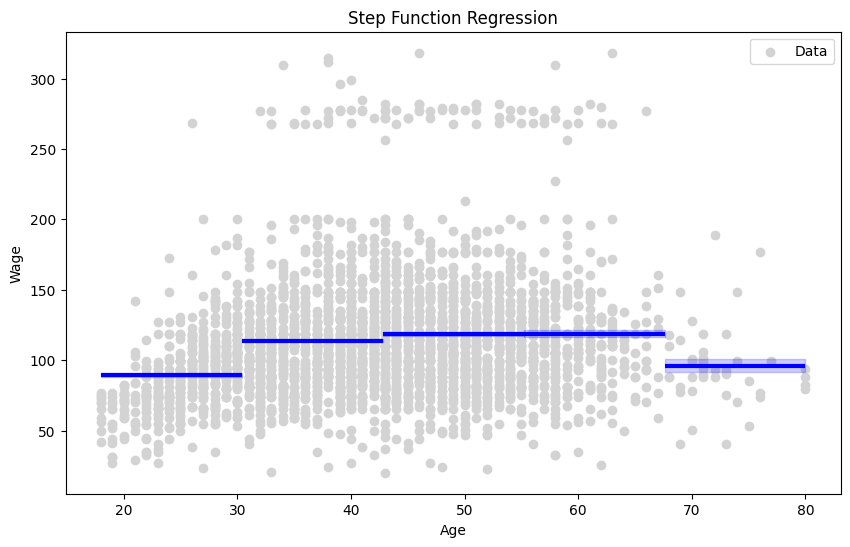

C:\Users\Johannes\AppData\Local\Temp\ipykernel_18852\449450733.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  step_probs = data.groupby('age_binned')['wage'].apply(lambda x: np.mean(x > 250))
C:\Users\Johannes\AppData\Local\Temp\ipykernel_18852\449450733.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_per_bin = data.groupby('age_binned')['wage'].count()


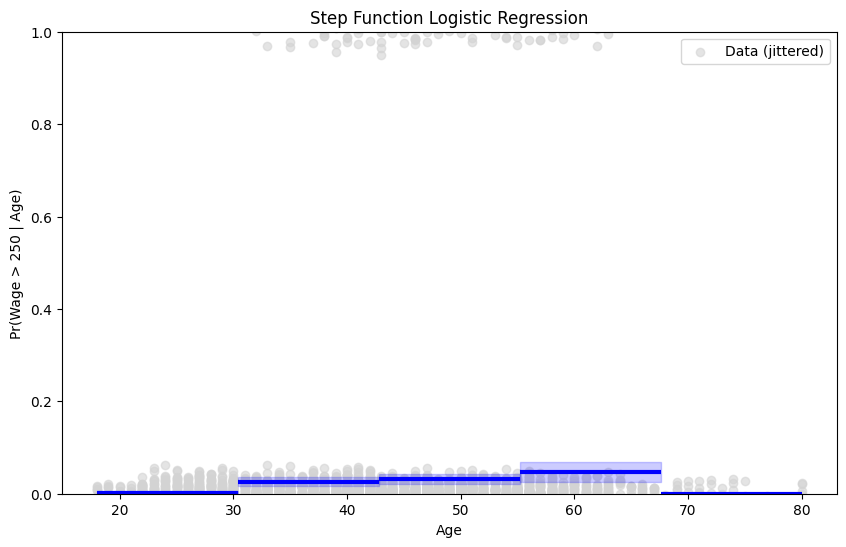

In [110]:
# Step function regression and logistic regression on Wage dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('data/Wage.csv')
X = data['age'].values
y = data['wage'].values

# Define number of bins
num_bins = 5
bin_edges = np.linspace(X.min(), X.max(), num_bins + 1)
bin_labels = [f'Bin {i}' for i in range(1, num_bins + 1)]

# Add binned age as a categorical variable
data['age_binned'] = pd.cut(data['age'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# -------------------------------
# Step function regression
# -------------------------------
step_means = data.groupby('age_binned')['wage'].mean()
step_se = data.groupby('age_binned')['wage'].sem()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='lightgray', label='Data')

for i in range(num_bins):
    plt.hlines(
        step_means.iloc[i],
        bin_edges[i],
        bin_edges[i + 1],
        colors='blue',
        lw=3
    )
    plt.fill_betweenx(
        [step_means.iloc[i] - step_se.iloc[i], step_means.iloc[i] + step_se.iloc[i]],
        bin_edges[i],
        bin_edges[i + 1],
        color='blue',
        alpha=0.2
    )

plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Step Function Regression')
plt.legend()
plt.show()

# -------------------------------
# Step function logistic regression
# -------------------------------
# Binary response: 1 if wage > 250, 0 otherwise
z = (y > 250).astype(int)

# Compute proportion in each bin (probability)
step_probs = data.groupby('age_binned')['wage'].apply(lambda x: np.mean(x > 250))
# Standard error for proportion: sqrt(p*(1-p)/n)
n_per_bin = data.groupby('age_binned')['wage'].count()
step_se_logit = np.sqrt(step_probs * (1 - step_probs) / n_per_bin)

plt.figure(figsize=(10, 6))
# Scatter plot with jitter for visualization
plt.scatter(X, z + np.random.normal(0, 0.02, size=len(z)), color='lightgray', alpha=0.6, label='Data (jittered)')

for i in range(num_bins):
    plt.hlines(
        step_probs.iloc[i],
        bin_edges[i],
        bin_edges[i + 1],
        colors='blue',
        lw=3
    )
    plt.fill_betweenx(
        [step_probs.iloc[i] - 1.96*step_se_logit.iloc[i], step_probs.iloc[i] + 1.96*step_se_logit.iloc[i]],
        bin_edges[i],
        bin_edges[i + 1],
        color='blue',
        alpha=0.2
    )

plt.xlabel('Age')
plt.ylabel('Pr(Wage > 250 | Age)')
plt.title('Step Function Logistic Regression')
plt.ylim(0, 1)
plt.legend()
plt.show()
    # Fit polynomial logistic regression of degree 4

## Basis Functions

Polynomial regression and step function regression are special cases of the **basis function approach**. 

The key idea is to define a set of **basis functions** $b_1(x), b_2(x), \dots, b_M(x)$, which transform the original predictor $X$ into a new feature space. We then fit a linear model in this transformed space:

$$
Y = \beta_0 + \sum_{m=1}^{M} \beta_m \, b_m(X) + \varepsilon
$$

Here, $b_m(X)$ are the basis functions, which we choose based on prior knowledge or modeling needs.

### Examples

1. **Polynomial Regression**  

   For a single predictor $x$, we can choose polynomial basis functions:

   $$
   b_1(x) = x, \quad b_2(x) = x^2, \quad \dots, \quad b_M(x) = x^M
   $$

   Then the model becomes the familiar polynomial regression model:

   $$
   Y = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_M x^M + \varepsilon
   $$

2. **Step Functions**  

   Here, we partition the predictor $x$ into $K$ bins and define **indicator basis functions**:

   $$
   b_k(x) = \mathbf{1}_{\{x \in \text{bin}_k\}}, \quad k=1,\dots,K
   $$

   The model is then piecewise constant:

   $$
   Y = \beta_0 + \sum_{k=1}^{K} \beta_k \, b_k(x) + \varepsilon
   $$

   This allows the prediction to vary **locally** within each bin, rather than fitting a single global function.

### Main Takeaways

- Basis functions provide a **general framework** to extend linear regression to capture non-linear relationships.
- Polynomial regression uses **global, smooth basis functions**, while step functions use **local, piecewise basis functions**.
- Once the basis functions $b_m(X)$ are defined, the model can be fit using standard **linear regression techniques** on the transformed predictors.
- Furthermore all inference tools like standard errors for the coefficient estimates and F-Statistics to gain insights on the model performance can be used as before.




## Regression splines
Splines are a more general form of basis functions or flexible class of basis functions that extend beyond polynomial regression and step wise regression. 

## Picewise polynomials
Pice wise polynomials are essentially the combination of step wise functions and polynomial fits involving fitting of low degree polynomial function on bins or pieces of the function. I.e. a pice wise cubic polynomial fits a cubic regression model on a pice or bin of X. To estimate y then for each bin of X a different set of cubic parameters are used. On the boundaries of the pieces or bins so called knots separate the individual polynomials. 

Increasing the number of knots lead to a higher flexibility for the modeling procedure of the data. On the boundaries of two polynomials the functions contain jumps and thus the function is not steady.

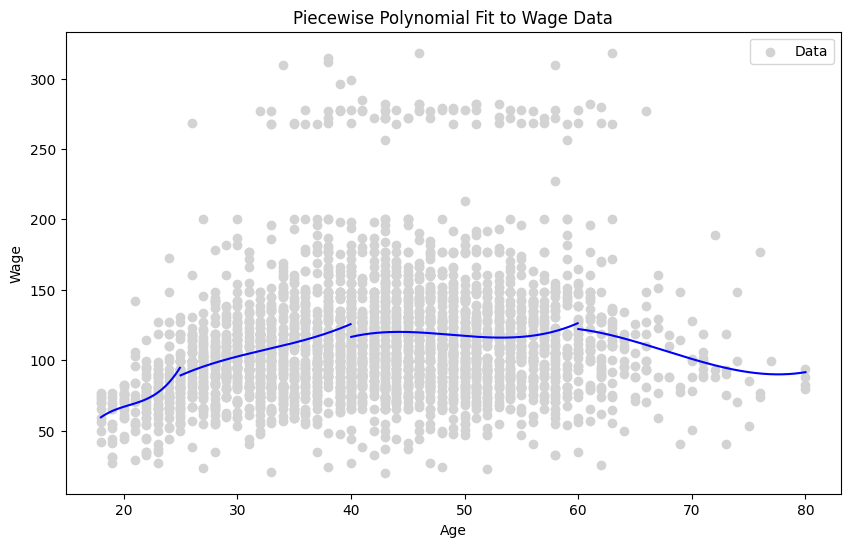

In [111]:
## Example piece wise polynomial fit to wage data set
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('data/Wage.csv')
X = data['age'].values
y = data['wage'].values
# Define knot points at ages 25, 40, and 60
knot_points = [25, 40, 60]

def piecewise_polynomial(X, y, knots, degree=3):
    """Fit a piecewise polynomial to the data.

    Args:
        X (np.ndarray): The input features.
        y (np.ndarray): The target values.
        knots (list): The knot points for the piecewise polynomial.
        degree (int, optional): The degree of the polynomial. Defaults to 3.
    """
    # Create design matrix in 3D space dim0 n samples, dim1 degree+1, dim2 number of segments
    n_segments = len(knots) + 1
    # divide data into segments based on knots
    segment_indices = np.digitize(X, bins=knots)
    X_segments = [X[segment_indices == i] for i in range(n_segments)]
    y_segments = [y[segment_indices == i] for i in range(n_segments)]

    # Fit separate polynomial to each segment
    models = []
    for X_segment, y_segment in zip(X_segments, y_segments):
        if len(X_segment) == 0:
            continue
        X_poly = np.vander(X_segment, degree + 1)
        model = np.linalg.lstsq(X_poly, y_segment, rcond=None)[0]
        models.append(model)
    return models, segment_indices

models, segment_indices = piecewise_polynomial(X, y, knot_points, degree=3)
# Plot the piecewise polynomial fit
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='lightgray', label='Data')
X_grid = np.linspace(X.min(), X.max(), 1000)
y_pred = np.zeros_like(X_grid)
segment_indices_grid = np.digitize(X_grid, bins=knot_points)
for i, model in enumerate(models):
    X_segment_grid = X_grid[segment_indices_grid == i]
    if len(X_segment_grid) == 0:
        continue
    X_poly_grid = np.vander(X_segment_grid, 4)
    y_segment_pred = X_poly_grid @ model
    y_pred[segment_indices_grid == i] = y_segment_pred
    plt.plot(X_segment_grid, y_segment_pred, color='blue')
plt.title('Piecewise Polynomial Fit to Wage Data')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.legend()
plt.show()


## Spline Basis Representation

### Motivation
Instead of fitting piecewise polynomials with explicit constraints, spline basis representations provide a convenient way to model smooth nonlinear relationships. Smoothness across knots is enforced implicitly through the choice of basis functions, allowing spline regression to be formulated as a standard linear regression problem.

### Cubic Splines and Smoothness Conditions
A **cubic spline** is a piecewise cubic polynomial with knots  
$\xi_1, \dots, \xi_K$, subject to the following conditions at each knot:

- Continuity of the function  
- Continuity of the first derivative  
- Continuity of the second derivative  

These constraints ensure a globally smooth curve.

### Truncated Power Basis Representation
A cubic spline can be written as
$$
f(x) = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3
+ \sum_{k=1}^{K} \gamma_k (x - \xi_k)_+^3,
$$
where
$$
(x - \xi)_+^3 =
\begin{cases}
(x - \xi)^3, & x > \xi, \\
0, & x \le \xi.
\end{cases}
$$

### Why the Truncated Term Ensures Smoothness
The truncated cubic term $(x - \xi_k)_+^3$ is constructed such that:

- For $x \le \xi_k$, the term is exactly zero.  
- For $x > \xi_k$, it behaves like a cubic polynomial.

At the knot $x = \xi_k$:
- The function value is zero from both sides.  
- The first derivative is zero from both sides.  
- The second derivative is zero from both sides.  

Therefore, adding $(x - \xi_k)_+^3$ does **not** introduce discontinuities in the function or its first two derivatives. Each knot only affects the curvature *to the right* of the knot, while preserving global smoothness. This is why spline continuity constraints are automatically satisfied.

---

### Model Setup
Spline regression is a linear model in transformed predictors. Given data
$$
\{(x_i, y_i)\}_{i=1}^n,
$$
the model is
$$
y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \beta_3 x_i^3
+ \sum_{k=1}^{K} \gamma_k (x_i - \xi_k)_+^3 + \varepsilon_i.
$$

In matrix form:
$$
\mathbf{y} = \mathbf{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon},
$$
where $\mathbf{X}$ contains the spline basis functions evaluated at $x_i$.

---

### Parameters to Be Estimated
From the data, we estimate:

- Polynomial coefficients:  
  $\beta_0, \beta_1, \beta_2, \beta_3$
- Knot coefficients:  
  $\gamma_1, \dots, \gamma_K$

All coefficients are fitted using **ordinary least squares** (or regularized variants).

---

### Number of Parameters for a Cubic Spline

For a cubic spline with $K$ knots, a total of

$$
4 + K
$$

parameters are estimated.

This follows directly from the truncated power basis representation:
$$
f(x) =
\underbrace{\beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3}_{\text{4 global parameters}}
\;+\;
\underbrace{\sum_{k=1}^{K} \gamma_k (x - \xi_k)_+^3}_{\text{$K$ additional parameters}}.
$$

- **4 parameters** ($\beta_0,\dots,\beta_3$):
  - correspond to a global cubic polynomial
  - control overall level, slope, curvature, and cubic trend

- **$K$ parameters** ($\gamma_1,\dots,\gamma_K$):
  - one coefficient per knot
  - control additional curvature introduced after each knot

The knot locations $\xi_k$ themselves are fixed and **not estimated** from the data.

---

### Connection to the Piecewise Polynomial View
Without any smoothness constraints, $K$ knots define $K+1$ intervals, each with a cubic polynomial:
- $4(K+1)$ coefficients in total

Cubic spline smoothness imposes, at each knot:
- continuity of the function
- continuity of the first derivative
- continuity of the second derivative

This gives $3K$ constraints, so the number of free parameters is:
$$
4(K+1) - 3K = 4 + K.
$$

The spline basis representation makes this reduction explicit and allows the model to be fit using standard linear regression.



### What Is Chosen vs. Fitted
- **Chosen by the practitioner:**  
  - Number of knots $K$  
  - Knot locations $\xi_1, \dots, \xi_K$

- **Fitted from the data:**  
  - All coefficients $\beta_j$ and $\gamma_k$

---

### Takeaway
- Cubic splines provide a flexible yet smooth way to model nonlinear relationships.  
- Smoothness across knots is guaranteed by the construction of the spline basis, not by explicit constraints.  
- Spline regression reduces to standard linear regression on nonlinear basis functions.  
- The bias–variance trade-off is controlled by the number and placement of knots.

> *Cubic splines trade flexibility for smoothness: by reducing the number of free parameters from $4(K+1)$ to $4+K$, they produce smoother, more stable fits with lower variance than unconstrained piecewise polynomial models.*


### Further topics
- Natural splines: Add linearity at the min and max of X to ensure that in the extrapolation region the predictions for Y not explode
- B-Splines: tbd






Design matrix shape: (3000, 7)


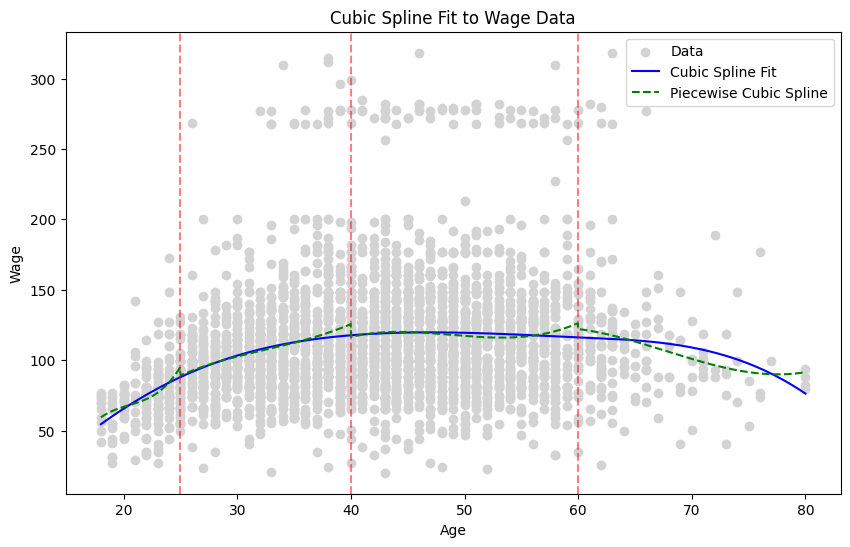

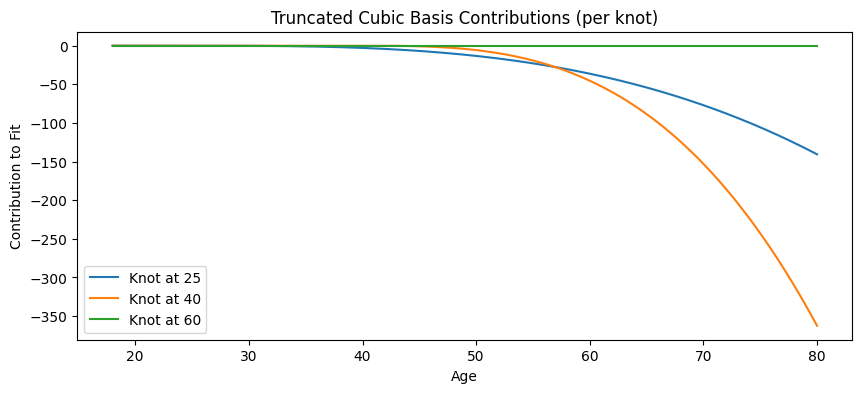

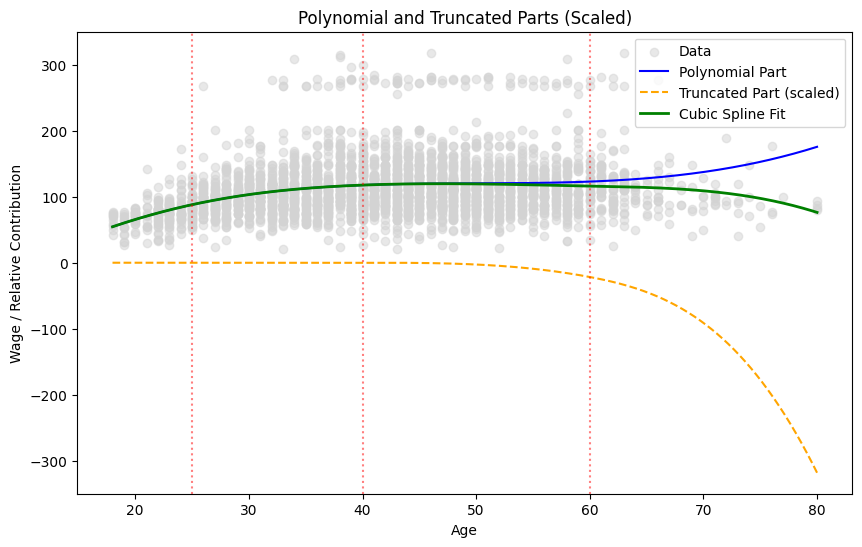

In [112]:
#Cubic spline fitting example on wage data set from scratch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('data/Wage.csv')
X = data['age'].values
y = data['wage'].values
# Define knot points at ages 25, 40, and 60
knot_points = [25, 40, 60]

def truncated_power_basis(X, knots, degree=3):
    """Create truncated power basis functions for cubic splines.

    Args:
        X (np.ndarray): The input features.
        knots (list): The knot points for the spline.
        degree (int, optional): The degree of the polynomial. Defaults to 3.
    """
    n = len(X)
    K = len(knots)
    # Initialize design matrix with intercept and polynomial terms + intercept
    X_design = np.zeros((n, degree + K + 1))
    # Fill in intercept term
    X_design[:, 0] = 1
    # Fill in polynomial terms
    for d in range(1, degree + 1):
        X_design[:, d] = X ** d
    # Fill in truncated power basis terms
    for k, knot in enumerate(knots):
        X_design[:, degree + k] = np.maximum(0, X - knot) ** degree
    return X_design

# Create design matrix using truncated power basis
X_design = truncated_power_basis(X, knot_points, degree=3)
# print the shape of X_design
print("Design matrix shape:", X_design.shape)
# Fit linear model using least squares
beta_hat = np.linalg.lstsq(X_design, y, rcond=None)[0]

# also fit a pice wise cubic polynomial for comparison
def piecewise_cubic_spline(X, y, knots):
    n_segments = len(knots) + 1
    segment_indices = np.digitize(X, bins=knots)
    X_segments = [X[segment_indices == i] for i in range(n_segments)]
    y_segments = [y[segment_indices == i] for i in range(n_segments)]

    models = []
    for X_segment, y_segment in zip(X_segments, y_segments):
        if len(X_segment) == 0:
            continue
        X_poly = np.vander(X_segment, 4)
        model = np.linalg.lstsq(X_poly, y_segment, rcond=None)[0]
        models.append(model)
    return models, segment_indices
models_pw, segment_indices_pw = piecewise_cubic_spline(X, y, knot_points)
# beta_hat now contains the coefficients for the spline basis functions [0:3] are for polynomial terms, [4:] are for truncated terms

# Plot the cubic spline fit
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='lightgray', label='Data')
X_grid = np.linspace(X.min(), X.max(), 1000)
X_grid_design = truncated_power_basis(X_grid, knot_points, degree=3)
y_grid_pred = X_grid_design @ beta_hat # Y = X * beta_hat
plt.plot(X_grid, y_grid_pred, color='blue', label='Cubic Spline Fit')
# add knot lines
for knot in knot_points:
    plt.axvline(x=knot, color='red', linestyle='--', alpha=0.5)

# also plot piece wise cubic spline for comparison
y_pw_pred = np.zeros_like(X_grid)
segment_indices_grid_pw = np.digitize(X_grid, bins=knot_points)
for i, model in enumerate(models_pw):
    X_segment_grid = X_grid[segment_indices_grid_pw == i]
    if len(X_segment_grid) == 0:
        continue
    X_poly_grid = np.vander(X_segment_grid, 4)
    y_segment_pred = X_poly_grid @ model
    y_pw_pred[segment_indices_grid_pw == i] = y_segment_pred
plt.plot(X_grid, y_pw_pred, color='green', linestyle='--', label='Piecewise Cubic Spline')
plt.title('Cubic Spline Fit to Wage Data')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.title("Truncated Cubic Basis Contributions (per knot)")

for k, knot in enumerate(knot_points):
    trunc_basis = np.maximum(0, X_grid - knot) ** 3 * beta_hat[4 + k]
    plt.plot(X_grid, trunc_basis, label=f'Knot at {knot}')

plt.xlabel("Age")
plt.ylabel("Contribution to Fit")
plt.legend()
plt.show()

# Plot polynomial part and sum of truncated parts separately
# Polynomial part
y_grid_poly = X_grid_design[:, :4] @ beta_hat[:4]

# Sum of truncated parts
y_grid_trunc = X_grid_design[:, 4:] @ beta_hat[4:]

# Total cubic spline fit
y_grid_total = y_grid_poly + y_grid_trunc


plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='lightgray', label='Data', alpha=0.5)

# Polynomial Part
plt.plot(X_grid, y_grid_poly, color='blue', label='Polynomial Part')

# Summe der Truncated Parts, skaliert für Sichtbarkeit
y_grid_trunc_scaled = y_grid_trunc / np.max(np.abs(y_grid_trunc)) * np.max(y)
plt.plot(X_grid, y_grid_trunc_scaled, color='orange', linestyle='--', label='Truncated Part (scaled)')

plt.plot(X_grid, y_grid_total, color='green', linewidth=2, label='Cubic Spline Fit')
for knot in knot_points:
    plt.axvline(x=knot, color='red', linestyle=':', alpha=0.5)

plt.xlabel("Age")
plt.ylabel("Wage / Relative Contribution")
plt.title("Polynomial and Truncated Parts (Scaled)")
plt.legend()
plt.show()





## Choosing the number and position of the knots
In praxis knots are placed in uniform fashion along X. The number of knots can be set by the desired degree of freedom e.g. if 4 dof are requested the knots are placed at the 25th 50th and 75th percentile. For the number of knots and the degree of freedom of the polynomial we use in the spline we can again use cross validation to tune this hyperparameter for different number of knots or different polynomial degrees and then observe the MSE or R2 statistics. 

## Smoothing Splines

### Motivation
Smoothing splines generalize cubic splines by allowing **flexible smoothing** rather than interpolating every data point.  
They are especially useful when we want a smooth fit without explicitly choosing knots.

---

### Problem Setup
Given data $\{(x_i, y_i)\}_{i=1}^n$, the smoothing spline $f(x)$ is defined as the function that **minimizes the penalized residual sum of squares**:

$$
\min_f \sum_{i=1}^{n} (y_i - f(x_i))^2 \;+\; \lambda \int (f''(x))^2 \, dx
$$

- The first term: ordinary least squares error  
- The second term: **penalty on roughness** (squared second derivative)  
- $\lambda \ge 0$: **smoothing parameter**, controls trade-off between bias and variance

---

### Key Properties
- $f(x)$ is a **natural cubic spline** with knots at each data point $x_i$  
- The smoothing parameter $\lambda$ controls flexibility:
  - $\lambda = 0$: **interpolates all data points** (very flexible)  
  - $\lambda \to \infty$: **reduces to a linear fit** (very smooth)
- The solution is **linear in $y$**:
  $$
  \hat{\mathbf{y}} = \mathbf{S}_\lambda \mathbf{y}
  $$
  where $\mathbf{S}_\lambda$ is the **smoother matrix** (depends on $\lambda$)

---

### Parameters
- Unlike regression splines, **no need to manually choose knots**  
- Only parameter to tune: **smoothing parameter $\lambda$**
- The function itself is represented in terms of its **values at the data points** (or equivalently, natural cubic spline coefficients)

---

### Bias–Variance Tradeoff
- Small $\lambda$: low bias, high variance → closely follows noisy data  
- Large $\lambda$: high bias, low variance → smooth global trend  
- Optimal $\lambda$ can be chosen via **cross-validation**

---

### Takeaway
- Smoothing splines are **automatic, flexible, and smooth** cubic splines  
- They avoid explicit knot placement by using a **penalty on curvature**  
- Conceptually, they are a **continuous version of penalized regression splines**
- The smoothing parameter $\lambda$ controls the **trade-off between fidelity to data and smoothness**


Optimal lambda via LOOCV: 100000.0
Effective Degrees of Freedom: 13.131271225165658


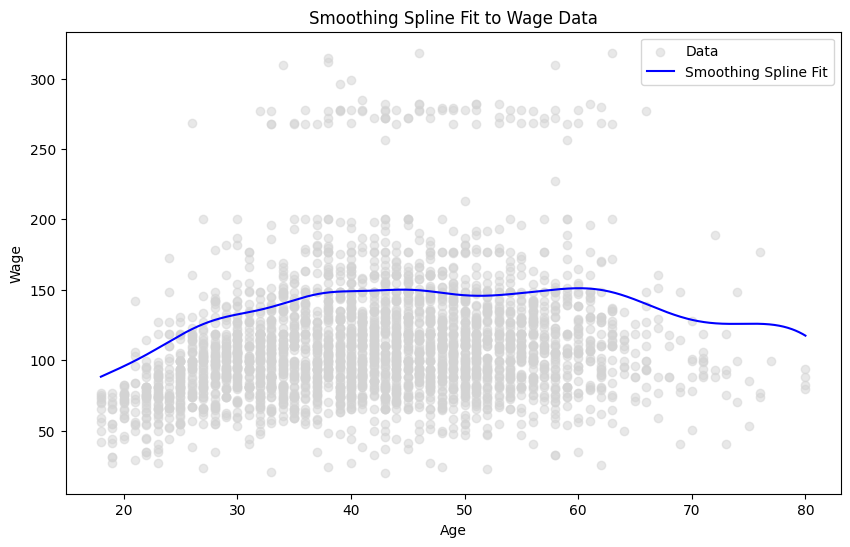

Effective Degrees of Freedom (Library): 4.000000000000001


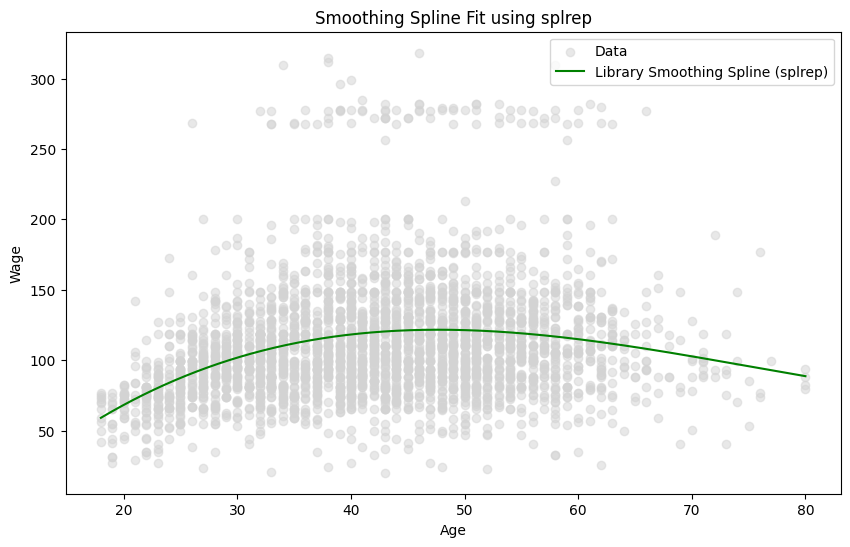

In [113]:
## ==============================
## Smoothing Splines Example on Wage Data Set (Fixed)
## ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load data
# ----------------------------
data = pd.read_csv('data/Wage.csv')
X = data['age'].values   # Predictor
y = data['wage'].values  # Response
n = len(y)

# =============================
# 1. Natural Cubic Spline Basis
# =============================
def natural_cubic_spline_basis(X, knots):
    """
    Construct a Natural Cubic Spline basis.
    
    X : array, shape (n,)
        Predictor values
    knots : array
        Knots for the spline (ideally sorted unique X values)
    
    Returns
    -------
    X_design : array, shape (n, K + 2)
        Design matrix with:
        - column 0: intercept
        - column 1: linear term
        - columns 2..K+1: truncated cubic basis functions
    """
    n = len(X)
    K = len(knots)
    X_design = np.zeros((n, K + 2))
    
    # Intercept (column 0)
    X_design[:, 0] = 1
    
    # Linear term (column 1)
    X_design[:, 1] = X
    
    # Truncated cubic basis functions (columns 2..K+1)
    # h_k(x) = (x - knot_k)^3_+ 
    for k, knot in enumerate(knots):
        X_design[:, k + 2] = np.maximum(0, X - knot) ** 3
    
    # Approximate natural spline constraints: second derivative at endpoints ≈ 0
    # Note: this is a simplified approximation; in practice B-splines or proper
    # natural spline formulas are more accurate.
    X_design[:, 2:] -= ((X_design[:, 2:] * (knots[-1] - knots[0])) /
                        (knots[-1] - knots[0])).mean(axis=0)
    
    return X_design

# Use all unique X values as knots
knots = np.unique(X)
X_design = natural_cubic_spline_basis(X, knots)

# =============================
# 2. Fit Smoothing Spline
# =============================
def fit_smoothing_spline(X_design, y, lam):
    """
    Fit a smoothing spline using a penalized least squares approach.
    
    The penalty is applied to the truncated cubic terms (columns 2+).
    
    X_design : array
        Design matrix
    y : array
        Response vector
    lam : float
        Smoothing parameter λ
        
    Returns
    -------
    beta_hat : array
        Estimated coefficients
    """
    n, p = X_design.shape
    
    # Penalty matrix: penalize only the truncated cubic coefficients
    D = np.zeros((p, p))
    for i in range(2, p):
        D[i, i] = 1  # scale for second derivative penalty
    
    # Solve (X^T X + λ D) β = X^T y
    A = X_design.T @ X_design + lam * D
    b = X_design.T @ y
    beta_hat = np.linalg.solve(A, b)
    return beta_hat

# =============================
# 3. LOOCV to find optimal lambda
# =============================
def find_optimal_lambda_using_loocv(X_design, y, lambda_values):
    """
    Find λ that minimizes Leave-One-Out Cross-Validation error.
    
    LOOCV formula: sum_i ((y_i - ŷ_i) / (1 - S_ii))^2
    """
    best_lambda = None
    best_loocv_error = float('inf')
    
    for lam in lambda_values:
        beta_hat = fit_smoothing_spline(X_design, y, lam)
        y_hat = X_design @ beta_hat
        
        # Compute hat matrix: S = X (X^T X + λ D)^(-1) X^T
        n, p = X_design.shape
        D = np.zeros((p, p))
        for i in range(2, p):
            D[i, i] = 1
        A_inv = np.linalg.inv(X_design.T @ X_design + lam * D)
        S_lam = X_design @ A_inv @ X_design.T
        
        # LOOCV error
        loocv_error = np.mean(((y - y_hat) / (1 - np.diag(S_lam))) ** 2)
        
        if loocv_error < best_loocv_error:
            best_loocv_error = loocv_error
            best_lambda = lam
            
    return best_lambda

# Candidate λ values
lambda_values = np.logspace(-2, 5, 30)  # coarse grid for numeric stability
optimal_lambda = find_optimal_lambda_using_loocv(X_design, y, lambda_values)
print("Optimal lambda via LOOCV:", optimal_lambda)

# =============================
# 4. Fit with optimal lambda
# =============================
beta_hat_opt = fit_smoothing_spline(X_design, y, optimal_lambda)

# Effective degrees of freedom: trace of hat matrix
n, p = X_design.shape
D = np.zeros((p, p))
for i in range(2, p):
    D[i, i] = 1
A_inv = np.linalg.inv(X_design.T @ X_design + optimal_lambda * D)
S_lam_opt = X_design @ A_inv @ X_design.T
edf = np.trace(S_lam_opt)
print("Effective Degrees of Freedom:", edf)

# =============================
# 5. Plot Smoothing Spline Fit
# =============================
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='lightgray', alpha=0.5, label='Data')

# Prediction on fine grid
X_grid = np.linspace(X.min(), X.max(), 1000)
X_grid_design = natural_cubic_spline_basis(X_grid, knots)
y_grid_pred = X_grid_design @ beta_hat_opt
plt.plot(X_grid, y_grid_pred, color='blue', label='Smoothing Spline Fit')

plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Smoothing Spline Fit to Wage Data')
plt.legend()
plt.show()


# =============================
# 6. Library-based version (scipy.interpolate)
# =============================
from scipy.interpolate import splrep, splev

# Sort X und y
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

# Entferne Duplikate durch Mittelung (falls mehrere y für gleiche x)
X_unique, idx_start = np.unique(X_sorted, return_index=True)
y_unique = np.array([y_sorted[X_sorted == xi].mean() for xi in X_unique])

# Jetzt ist X_unique streng monoton steigend
tck = splrep(X_unique, y_unique, s=10E9, k=3)

# calculate effective degrees of freedom
n_unique = len(X_unique)
H = np.zeros((n_unique, n_unique))
for i in range(n_unique):
    e_i = np.zeros(n_unique)
    e_i[i] = 1
    H[:, i] = splev(X_unique, splrep(X_unique, e_i, s=10E9, k=3))
edf_lib = np.trace(H)
print("Effective Degrees of Freedom (Library):", edf_lib)

# Evaluate
X_grid = np.linspace(X_unique.min(), X_unique.max(), 1000)
y_grid_lib = splev(X_grid, tck)


# Plot
plt.figure(figsize=(10,6))
plt.scatter(X_sorted, y_sorted, color='lightgray', alpha=0.5, label='Data')
plt.plot(X_grid, y_grid_lib, color='green', label='Library Smoothing Spline (splrep)')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Smoothing Spline Fit using splrep')
plt.legend()
plt.show()


## Local Regression (Loess / Lowess)

### Motivation
Local regression is a **nonparametric method** that fits **flexible, local polynomials** around each target point.  
It is especially useful when the global relationship between predictor and response is **nonlinear** and cannot be captured by a single global model.

---

### Problem Setup
Given data $\{(x_i, y_i)\}_{i=1}^n$, the local regression estimate at a target point $x_0$ is defined as the solution to a **weighted least squares problem**:

$$
\hat{f}(x_0) = \arg\min_\beta \sum_{i=1}^{n} w_i(x_0) \big(y_i - \beta_0 - \beta_1(x_i - x_0) - \dots \big)^2
$$

- $w_i(x_0)$: **kernel weight** decreasing with distance from $x_0$  
- $\beta$: **local polynomial coefficients** of degree $d$  
- Span / bandwidth $h$: controls the size of the local neighborhood around $x_0$

**Example: tricube kernel**
$$
w_i(x_0) = \left( 1 - \left| \frac{x_i - x_0}{h} \right|^3 \right)^3, \quad |x_i - x_0| < h
$$

- The kernel ensures that **closer points contribute more** to the local fit

---

### Key Properties
- Fits a **polynomial locally** at each point $x_0$  
- Weighted by a **kernel**: local weighting function  
- Degree of polynomial $d$ determines flexibility:
  - $d=0$: locally constant → equivalent to weighted moving average  
  - $d=1$: locally linear → typical default  
  - $d=2$: locally quadratic → allows local curvature  
- Smoothness is controlled by the **span/bandwidth**:
  - Small span → very flexible, can overfit  
  - Large span → smoother, may underfit

---

### Parameters
- **Span / bandwidth $h$**: fraction of data used for each local fit  
- **Polynomial degree $d$**: degree of local polynomial  
- **Kernel function** (e.g., tricube, Gaussian)  
- No global functional form or knots are needed  

---

### Bias–Variance Tradeoff
- Small span: low bias, high variance → closely follows noisy data  
- Large span: high bias, low variance → smooth global trend  
- Choice of span can be optimized via **cross-validation**

---

### Takeaway
- Local regression is a **flexible, kernel-weighted local fit**  
- Conceptually, it is a **continuous, moving weighted regression**  
- Degree of polynomial and span control **flexibility and smoothness**  
- It generalizes weighted moving averages (degree 0) and linear smoothing (degree 1)


## Local Regression Algorithm (Step-by-Step)

### Motivation
Local regression fits **flexible, smooth curves** by estimating a **local polynomial** at each target point.  
It generalizes weighted moving averages to allow **local linear or quadratic trends**.

---

### Algorithm

Given train dataset $\{(x_i, y_i)\}_{i=1}^n$, for each target point $x_0$ where we want to make a prediction:

1. **Define local neighborhood (span / bandwidth)**  
   - Choose fraction of data points $0 < f \le 1$ to use in the local fit.  
   - Denote the **span** as $f \cdot n$.  
   - Let $h$ be the distance from $x_0$ to the furthest neighbor in this span.

2. **Compute weights using a kernel function**  
   - For each point $x_i$ in the neighborhood, compute a weight $w_i(x_0)$ that decreases with distance to $x_0$:  
   \[
   w_i(x_0) = K\left(\frac{|x_i - x_0|}{h}\right)
   \]  
   - Common choice: **tricube kernel**:  
   \[
   K(u) = (1 - |u|^3)^3, \quad |u| < 1
   \]  
   - Points outside the span get $w_i = 0$.

3. **Fit a weighted local polynomial**  
   - Form the local polynomial design matrix $X_{\text{local}}$ of degree $d$:
     \[
     X_{\text{local}} = 
     \begin{bmatrix}
     1 & (x_1 - x_0) & (x_1 - x_0)^2 & \dots & (x_1 - x_0)^d \\
     \vdots & \vdots & \vdots & & \vdots \\
     1 & (x_k - x_0) & (x_k - x_0)^2 & \dots & (x_k - x_0)^d
     \end{bmatrix}
     \]  
   - Solve **weighted least squares**:  
   \[
   \hat{\beta} = \arg\min_\beta \sum_{i=1}^k w_i (y_i - X_{\text{local}, i} \beta)^2
   \]

4. **Compute the fitted value at $x_0$**  
   - The prediction is the polynomial evaluated at $x_0$ (centered):
   \[
   \hat{f}(x_0) = \hat{\beta}_0
   \]

5. **Repeat for all target points**  
   - Iterate steps 1–4 over a grid of $x_0$ (or all $x_i$) to obtain a smooth curve.

---

### Optional: Robust Loess
- After the first fit, compute residuals $r_i = y_i - \hat{f}(x_i)$  
- Reweight points with **robust weights** (e.g., bisquare function)  
- Refit local polynomials with updated weights → reduces effect of outliers  

---

### Key Parameters
| Parameter | Role |
|-----------|------|
| Span / bandwidth $f$ | Fraction of data in local neighborhood; controls smoothness |
| Polynomial degree $d$ | 0 = constant, 1 = linear (default), 2 = quadratic |
| Kernel $K(u)$ | Weighting function (tricube, Gaussian, etc.) |
| Robust iterations | Optional reweighting for outlier resistance |

---

### Takeaways
- Local regression is **kernel-weighted local polynomial fitting**  
- Small span → flexible, high variance; large span → smooth, low variance  
- Degree controls local shape: constant, linear, or quadratic  
- It generalizes **weighted moving averages** (degree 0) and can mimic **smoothing splines** in behavior


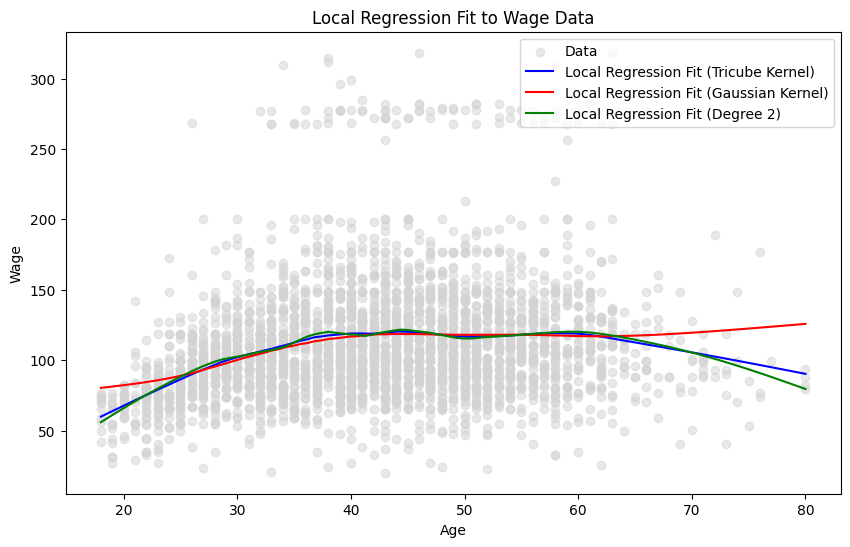

In [114]:
# local regression example on wage data set from scratch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('data/Wage.csv')
X = data['age'].values
y = data['wage'].values
# =============================
# 1. Local Regression Function
# =============================

def local_regression(X, y, x0, span, kernel='tricube', degree=1):
    """
    Perform local linear regression at point x0 using a tricube weight function.
    
    X : array, shape (n,)
        Predictor values
    y : array, shape (n,)
        Response values
    x0 : float
        Target point for prediction
    span : float
        Fraction of data to include in local fit (0 < span <= 1)
    
    Returns
    -------
    y0_pred : float
        Predicted value at x0
    """
    n = len(X)
    # Determine bandwidth
    k = int(np.ceil(span * n))
    distances = np.abs(X - x0)
    sorted_indices = np.argsort(distances)
    bandwidth = distances[sorted_indices[k - 1]]
    
    # Compute weights using tricube kernel
    weights = np.zeros(n)
    if kernel == 'tricube':
        for i in range(n):
            u = distances[i] / bandwidth
            if u < 1:
                weights[i] = (1 - u ** 3) ** 3
    elif kernel == 'gaussian':
        weights = np.exp(-0.5 * (distances / bandwidth) ** 2)
    else:
        raise ValueError("Unsupported kernel type.")

    
    # Fit weighted linear regression
    W = np.diag(weights)
    if degree == 1:
        X_design = np.vstack((np.ones(n), X)).T
    elif degree == 2:
        X_design = np.vstack((np.ones(n), X, X**2)).T
    elif degree == 3:
        X_design = np.vstack((np.ones(n), X, X**2, X**3)).T
    else:
        raise ValueError("Unsupported degree.")
    # Compute coefficients beta_hat around local point x0
    beta_hat = np.linalg.inv(X_design.T @ W @ X_design) @ (X_design.T @ W @ y)
    
    # Predict at x0 
    if degree == 1:
        x0_design = np.array([1, x0])
    elif degree == 2:
        x0_design = np.array([1, x0, x0**2])
    elif degree == 3:
        x0_design = np.array([1, x0, x0**2, x0**3])
    y0_pred = x0_design @ beta_hat
    return y0_pred

# =============================
# 2. Fit Local Regression over Grid
# =============================
span = 0.3  # 30% of data for local fit
X_grid = np.linspace(X.min(), X.max(), 100)
y_grid_pred = np.array([local_regression(X, y, x0, span, kernel='tricube', degree=1) for x0 in X_grid])
# now with gaussian kernel

y_grid_pred_gaussian = np.array([local_regression(X, y, x0, span, kernel='gaussian', degree=1) for x0 in X_grid])

# now with degree 2 polynomial
y_grid_pred_degree2 = np.array([local_regression(X, y, x0, span, kernel='tricube', degree=2) for x0 in X_grid])

# =============================
# 3. Plot Local Regression Fit
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='lightgray', alpha=0.5, label='Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Local Regression Fit (Tricube Kernel)')
plt.plot(X_grid, y_grid_pred_gaussian, color='red', label='Local Regression Fit (Gaussian Kernel)')
plt.plot(X_grid, y_grid_pred_degree2, color='green', label='Local Regression Fit (Degree 2)')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Local Regression Fit to Wage Data')
plt.legend()
plt.show()

## =============================

## Generalized Additive Models (GAMs)

### Motivation
GAMs generalize linear models by allowing **nonlinear functions of each predictor**, while still keeping the model **additive**:

$$
Y = \beta_0 + f_1(X_1) + f_2(X_2) + \dots + f_p(X_p) + \varepsilon
$$

- Each $f_j(X_j)$ can be a **smooth function** (e.g., spline, local regression)  
- Additivity keeps the model **interpretable** and **estimable**, avoiding the curse of dimensionality of full multivariate nonparametric regression

---

### Problem Setup
Given predictors $X_1, \dots, X_p$ and response $Y$:

$$
Y_i = \beta_0 + \sum_{j=1}^p f_j(X_{ij}) + \varepsilon_i, \quad i=1,\dots,n
$$

- $\varepsilon_i$ are independent errors  
- $f_j$ are **smooth, potentially nonlinear functions**  
- Goal: estimate each $f_j$ **without assuming a parametric form**, using techniques like:
  - Splines (regression, smoothing)  
  - Local regression (Loess / Lowess)  

### Choosing the functions $f_1, \dots, f_p$
- **Numerical variables** → typically **splines** (cubic, natural, B-splines) or **loess**  
- **Categorical variables** → factor / dummy coding  
- Avoid fully multivariate nonparametric fits → additive structure prevents curse of dimensionality  


| Function type | Description | When to use |
|---------------|------------|-------------|
| **Splines** (e.g., cubic, natural, B-splines) | Smooth curves, explicit control of smoothness via number of knots and penalty | When nonlinear, smooth trends are expected |
| **Local Regression (Loess / Lowess)** | Flexible local fitting, no fixed knots required | When effects vary strongly locally |
| **Polynomials** | Parametric function $X^d$ | For simple, global curvature |
| **Step functions / piecewise** | Discrete jumps | For categorical or segmented effects |

---

### Hyperparameters
- **Smoothing parameter $\lambda$** → controls smoothness of each $f_j$  
- **Number of knots** (splines) → more knots = more flexible  
- **Polynomial degree / local span** (loess) → controls local flexibility  

> Strategy: choose via cross-validation, then visualize $f_j(X_j)$ to check plausibility


---

### Estimation
- GAMs are usually fitted **iteratively**, using **backfitting algorithm**:

1. Initialize all $f_j$ (e.g., $f_j = 0$)  
2. Iterate over each predictor $j$:
   - Fit $f_j(X_j)$ **to the partial residuals**:  
   $$
   R_j = Y - \beta_0 - \sum_{k \neq j} f_k(X_k)
   $$  
   - Using **a smoothing method** (spline, local regression)  
3. Repeat until convergence  

- The intercept $\beta_0$ is usually estimated as the **mean of $Y$** minus the sum of smooths

---

### Key Properties
- Additive: the effect of each predictor is **modeled separately**  
- Nonparametric: **each $f_j$ can be flexible**, capturing nonlinear trends  
- Interpretation: easy to visualize each $f_j$ individually

### Bias–Variance Tradeoff
- Flexible $f_j$ → low bias, high variance  
- Smoother $f_j$ → high bias, low variance  
- Each smoother parameter can be **tuned separately**, e.g., via cross-validation

---

### Takeaways
- GAMs combine **additive structure** and **flexible nonparametric smooths**  
- They generalize linear models while retaining **interpretability**  
- Each predictor can be plotted against its estimated function $f_j(X_j)$ to understand its effect  
- GAMs are a **bridge between parametric linear models and fully nonparametric multivariate regression**


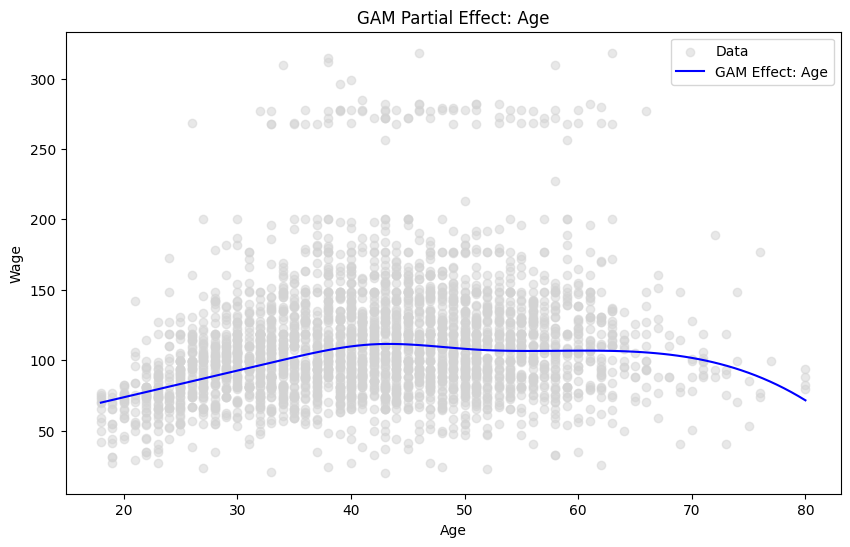

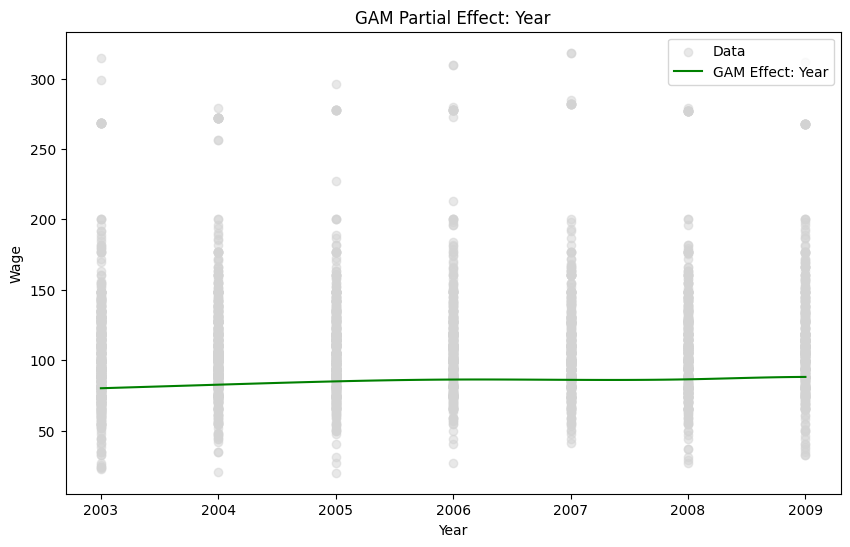

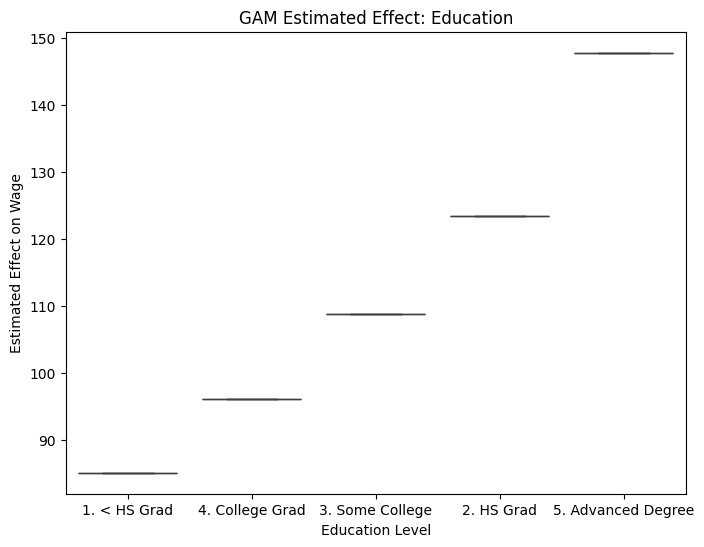

In [115]:
## ==============================
## GAM on Wage Dataset (Fixed Partial Effects)
## ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load data
# ----------------------------
data = pd.read_csv('data/Wage.csv')
X_age = data['age'].values
X_year = data['year'].values
X_edu = data['education'].values
y = data['wage'].values

# ----------------------------
# Spline basis function
# ----------------------------
def natural_cubic_spline_basis(X, knots):
    n = len(X)
    K = len(knots)
    X_design = np.zeros((n, K + 2))
    X_design[:, 0] = 1  # intercept
    X_design[:, 1] = X  # linear term
    for k, knot in enumerate(knots):
        X_design[:, k + 2] = np.maximum(0, X - knot) ** 3
    # approximate natural spline constraints
    X_design[:, 2:] -= ((X_design[:, 2:] * (knots[-1] - knots[0])) / 
                        (knots[-1] - knots[0])).mean(axis=0)
    return X_design

# ----------------------------
# Create spline basis for age and year
# ----------------------------
age_knots = np.percentile(X_age, [25, 50, 75])
year_knots = np.percentile(X_year, [25, 50, 75])
X_age_spline = natural_cubic_spline_basis(X_age, age_knots)
X_year_spline = natural_cubic_spline_basis(X_year, year_knots)

# One-hot encode education (factor variable)
edu_dummies = pd.get_dummies(X_edu, prefix='edu', drop_first=True).values

# ----------------------------
# Combine design matrix and fit linear model
# ----------------------------
X_design = np.hstack([X_age_spline, X_year_spline, edu_dummies])
beta_hat = np.linalg.lstsq(X_design, y, rcond=None)[0]

# ----------------------------
# Partial effect: Age
# ----------------------------
age_grid = np.linspace(X_age.min(), X_age.max(), 100)
# fix year and education
year_fixed = np.median(X_year)
edu_fixed = np.zeros(edu_dummies.shape[1])
age_grid_spline = natural_cubic_spline_basis(age_grid, age_knots)
year_fixed_spline = natural_cubic_spline_basis(np.full_like(age_grid, year_fixed), year_knots)
X_grid_age = np.hstack([age_grid_spline, year_fixed_spline, np.tile(edu_fixed, (100,1))])
y_age_effect = X_grid_age @ beta_hat

plt.figure(figsize=(10,6))
plt.scatter(X_age, y, color='lightgray', alpha=0.5, label='Data')
plt.plot(age_grid, y_age_effect, color='blue', label='GAM Effect: Age')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('GAM Partial Effect: Age')
plt.legend()
plt.show()

# ----------------------------
# Partial effect: Year
# ----------------------------
year_grid = np.linspace(X_year.min(), X_year.max(), 100)
# fix age and education
age_fixed = np.median(X_age)
edu_fixed = np.zeros(edu_dummies.shape[1])
year_grid_spline = natural_cubic_spline_basis(year_grid, year_knots)
age_fixed_spline = natural_cubic_spline_basis(np.full_like(year_grid, age_fixed), age_knots)
X_grid_year = np.hstack([age_fixed_spline, year_grid_spline, np.tile(edu_fixed, (100,1))])
y_year_effect = X_grid_year @ beta_hat

plt.figure(figsize=(10,6))
plt.scatter(X_year, y, color='lightgray', alpha=0.5, label='Data')
plt.plot(year_grid, y_year_effect, color='green', label='GAM Effect: Year')
plt.xlabel('Year')
plt.ylabel('Wage')
plt.title('GAM Partial Effect: Year')
plt.legend()
plt.show()

# ----------------------------
# Partial effect: Education (Boxplots)
# ----------------------------
import seaborn as sns

# Compute fitted values for each education level
edu_levels = data['education'].unique()
edu_effects = []
for level in edu_levels:
    # One-hot encoding for this level
    edu_dummy = np.zeros(edu_dummies.shape[1])
    if level != edu_levels[0]:  # drop_first=True baseline
        idx = list(edu_levels[1:]).index(level)
        edu_dummy[idx] = 1
    
    # Fixed median age and year
    X_grid_edu = np.hstack([
        natural_cubic_spline_basis(np.full(1, np.median(X_age)), age_knots),
        natural_cubic_spline_basis(np.full(1, np.median(X_year)), year_knots),
        edu_dummy.reshape(1, -1)
    ])
    
    y_edu_effect = X_grid_edu @ beta_hat
    edu_effects.append(y_edu_effect[0])

# Plot as boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x=edu_levels, y=edu_effects)
plt.xlabel('Education Level')
plt.ylabel('Estimated Effect on Wage')
plt.title('GAM Estimated Effect: Education')
plt.show()


## Backfitting Algorithm for GAMs

### Motivation
The **backfitting algorithm** is used to fit Generalized Additive Models (GAMs) of the form:

$$
Y = \beta_0 + f_1(X_1) + f_2(X_2) + \dots + f_p(X_p) + \varepsilon
$$

- Each $f_j$ is a smooth function of predictor $X_j$  
- Additivity allows separate estimation of each $f_j$  
- Backfitting is an **iterative algorithm** to estimate all $f_j$ efficiently

---

### Algorithm Steps
1. **Initialize** all smooth functions to zero: $f_j^{(0)}(X_j) = 0$  
   Set intercept $\beta_0 = \frac{1}{n} \sum_i Y_i$
2. **Iteratively update each $f_j$**:
   - Compute partial residuals:  
     $$
     R_j = Y - \beta_0 - \sum_{k \neq j} f_k(X_k)
     $$
   - Fit a smoother: $f_j \gets \text{smooth}(X_j, R_j)$  
   - Center $f_j$ to have mean zero
3. **Repeat** until convergence (changes in $f_j$ are small)
4. **Final model**:  
   $$
   \hat{Y} = \beta_0 + \sum_j f_j(X_j)
   $$

---

### Key Properties
- Each smoother $f_j$ is fit to the **residuals of other predictors**, isolating its effect  
- Works with any smoothers: splines, loess, kernel regression  
- Computationally efficient, avoids high-dimensional nonparametric regression  
- Converges in a few iterations for typical smoothers


Iteration 1: RSS = 5499133.8885, Intercept = 7.65
Iteration 2: RSS = 5466475.7628, Intercept = 7.60
Iteration 3: RSS = 5466471.7194, Intercept = 7.59
Iteration 4: RSS = 5466472.1055, Intercept = 7.59
Iteration 5: RSS = 5466472.1140, Intercept = 7.59
Iteration 6: RSS = 5466472.1142, Intercept = 7.59
Iteration 7: RSS = 5466472.1142, Intercept = 7.59
Iteration 8: RSS = 5466472.1142, Intercept = 7.59
Iteration 9: RSS = 5466472.1142, Intercept = 7.59
Iteration 10: RSS = 5466472.1142, Intercept = 7.59


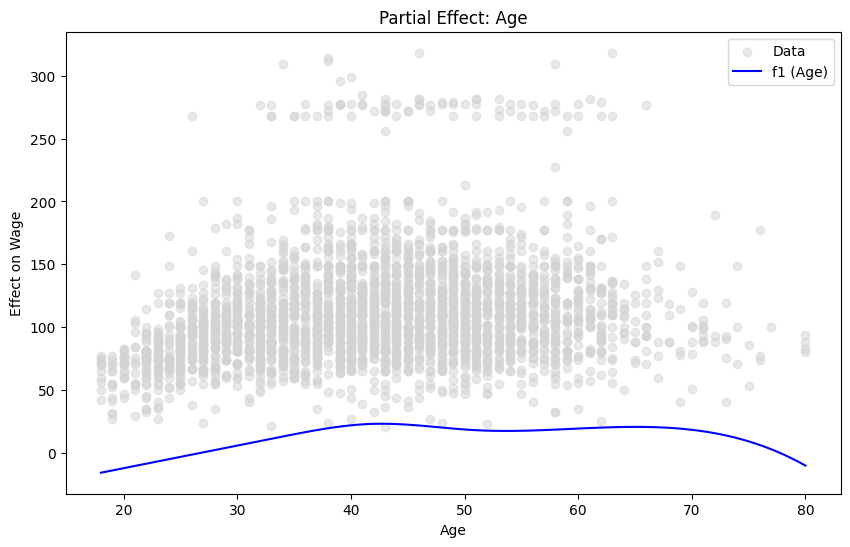

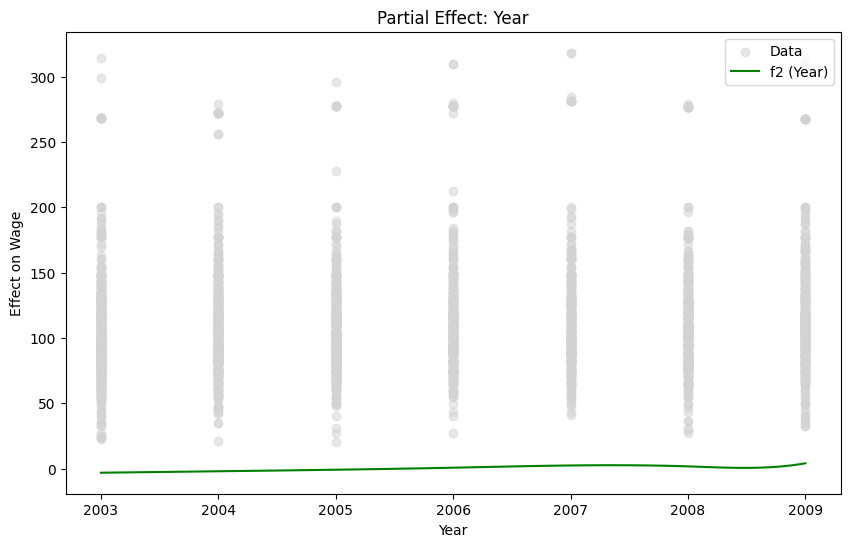

C:\Users\Johannes\AppData\Local\Temp\ipykernel_18852\3880633717.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(edu_vals, labels=edu_levels[1:])  # first level is baseline


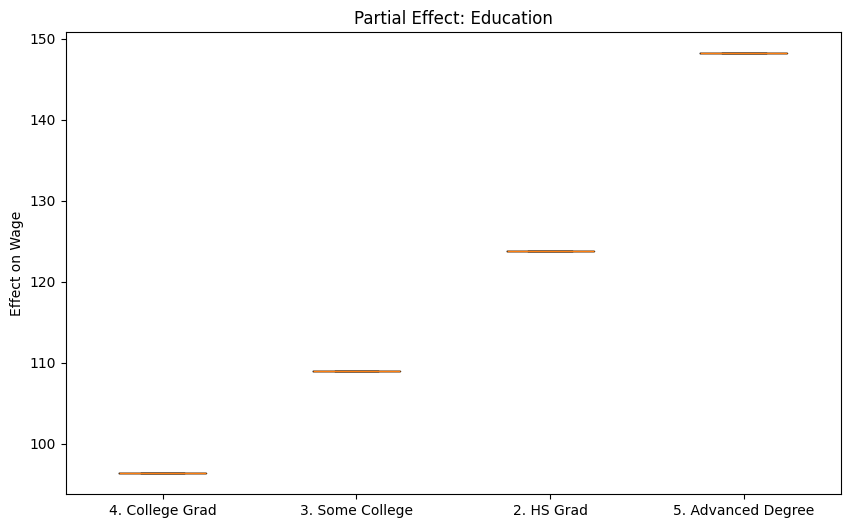

interactive(children=(IntSlider(value=0, description='Iteration', max=9), Output()), _dom_classes=('widget-int…

In [ ]:
## Backfitting algorithm for GAMs (Fixed Partial Effects) on the Wage dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load data
data = pd.read_csv('data/Wage.csv')
X1 = data['age'].values
X2 = data['year'].values
X3 = data['education'].values
y = data['wage'].values
n = len(y)
# One-hot encode education
edu_dummies = pd.get_dummies(X3, prefix='edu', drop_first=True).values
# Implement smoothing spline basis
def natural_cubic_spline_basis(X, knots):
    n = len(X)
    K = len(knots)
    X_design = np.zeros((n, K + 2))
    X_design[:, 0] = 1  # intercept
    X_design[:, 1] = X  # linear term
    for k, knot in enumerate(knots):
        X_design[:, k + 2] = np.maximum(0, X - knot) ** 3
    # approximate natural spline constraints
    X_design[:, 2:] -= ((X_design[:, 2:] * (knots[-1] - knots[0])) / 
                        (knots[-1] - knots[0])).mean(axis=0)
    return X_design
# Create spline basis for age and year
age_knots = np.percentile(X1, [25, 50, 75])
year_knots = np.percentile(X2, [25, 50, 75])
X1_spline = natural_cubic_spline_basis(X1, age_knots)
X2_spline = natural_cubic_spline_basis(X2, year_knots)

# Backfitting algorithm
def backfitting_gam_fixed(X1_spline, X2_spline, edu_dummies, y, n_iters=10):
    n = len(y)
    # Initialize partial effects
    f1 = np.zeros(n)
    f2 = np.zeros(n)
    f3 = np.zeros(n)
    intercept = np.mean(y)
    f1_history = []
    f2_history = []
    f3_history = []
    
    for it in range(n_iters):
        # Update f1 (age effect)
        r1 = y - f2 - f3
        beta1 = np.linalg.lstsq(X1_spline, r1, rcond=None)[0]
        f1 = X1_spline @ beta1
        f1 -= np.mean(f1)
        f1_history.append(f1)
        
        # Update f2 (year effect)
        r2 = y - f1 - f3
        beta2 = np.linalg.lstsq(X2_spline, r2, rcond=None)[0]
        f2 = X2_spline @ beta2
        f2 -= np.mean(f2)
        f2_history.append(f2)

        
        # Update f3 (education effect)
        r3 = y - f1 - f2
        beta3 = np.linalg.lstsq(edu_dummies, r3, rcond=None)[0]
        f3 = edu_dummies @ beta3
        # do not subtract mean for dummy variables
        # f3 -= np.mean(f3)
        
        # Update intercept based on residual
        intercept = np.mean(y - f1 - f2 - f3)
        f3_history.append(f3)
        
        # Optional: print RSS
        rss = np.sum((y - (intercept + f1 + f2 + f3))**2)
        print(f"Iteration {it+1}: RSS = {rss:.4f}, Intercept = {intercept:.2f}")
        
    return intercept, f1, f2, f3, f1_history, f2_history, f3_history


intercept, f1, f2, f3, f1_history, f2_history, f3_history = backfitting_gam_fixed(X1_spline, X2_spline, edu_dummies, y, n_iters=10)

# Plot age effect
plt.figure(figsize=(10,6))
plt.scatter(X1, y, color='lightgray', alpha=0.5, label='Data')
age_grid = np.linspace(X1.min(), X1.max(), 100)
age_grid_spline = natural_cubic_spline_basis(age_grid, age_knots)
f1_grid = age_grid_spline @ np.linalg.lstsq(X1_spline, f1, rcond=None)[0]
plt.plot(age_grid, f1_grid, color='blue', label='f1 (Age)')
plt.xlabel('Age')
plt.ylabel('Effect on Wage')
plt.title('Partial Effect: Age')
plt.legend()
plt.show()

# Plot year effect
plt.figure(figsize=(10,6))
plt.scatter(X2, y, color='lightgray', alpha=0.5, label='Data')
year_grid = np.linspace(X2.min(), X2.max(), 100)
year_grid_spline = natural_cubic_spline_basis(year_grid, year_knots)
f2_grid = year_grid_spline @ np.linalg.lstsq(X2_spline, f2, rcond=None)[0]
plt.plot(year_grid, f2_grid, color='green', label='f2 (Year)')
plt.xlabel('Year')
plt.ylabel('Effect on Wage')
plt.title('Partial Effect: Year')
plt.legend()
plt.show()

# Plot education effect as boxplot
edu_levels = data['education'].unique()
edu_vals = [f3[edu_dummies[:, i] == 1] for i in range(edu_dummies.shape[1])]
plt.figure(figsize=(10,6))
plt.boxplot(edu_vals, labels=edu_levels[1:])  # first level is baseline
plt.ylabel('Effect on Wage')
plt.title('Partial Effect: Education')
plt.show()

#
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# f1_history, f2_history, f3_history from your backfitting function
# n_iters = number of iterations

def plot_backfitting_iteration(iter_idx):
    plt.figure(figsize=(15, 4))

    # -----------------------------
    # f1 (age)
    # -----------------------------
    plt.subplot(1, 3, 1)
    age_grid = np.linspace(X1.min(), X1.max(), 100)
    age_grid_spline = natural_cubic_spline_basis(age_grid, age_knots)
    # project current iteration's f1 onto grid
    f1_grid = age_grid_spline @ np.linalg.lstsq(X1_spline, f1_history[iter_idx], rcond=None)[0]
    plt.plot(age_grid, f1_grid, color='blue', label=f'f1 (iteration {iter_idx+1})')
    plt.scatter(X1, f1_history[iter_idx], color='lightblue', alpha=0.3, s=10)  # optional: data points
    plt.xlabel('Age')
    plt.ylabel('Partial Effect')
    plt.title('f1: Age Effect')
    plt.legend()

    # -----------------------------
    # f2 (year)
    # -----------------------------
    plt.subplot(1, 3, 2)
    year_grid = np.linspace(X2.min(), X2.max(), 100)
    year_grid_spline = natural_cubic_spline_basis(year_grid, year_knots)
    f2_grid = year_grid_spline @ np.linalg.lstsq(X2_spline, f2_history[iter_idx], rcond=None)[0]
    plt.plot(year_grid, f2_grid, color='green', label=f'f2 (iteration {iter_idx+1})')
    plt.scatter(X2, f2_history[iter_idx], color='lightgreen', alpha=0.3, s=10)  # optional: data points
    plt.xlabel('Year')
    plt.ylabel('Partial Effect')
    plt.title('f2: Year Effect')
    plt.legend()

    # -----------------------------
    # f3 (education)
    # -----------------------------
    plt.subplot(1, 3, 3)
    # group values by education dummy columns
    edu_vals = [f3_history[iter_idx][edu_dummies[:, i] == 1] for i in range(edu_dummies.shape[1])]
    plt.boxplot(edu_vals, labels=data['education'].unique()[1:])  # baseline level is first
    plt.ylabel('Partial Effect')
    plt.title(f'f3: Education Effect (iteration {iter_idx+1})')

    plt.tight_layout()
    plt.show()


# Interactive slider
interact(plot_backfitting_iteration,
         iter_idx=IntSlider(min=0, max=len(f1_history)-1, step=1, value=0, description='Iteration'));


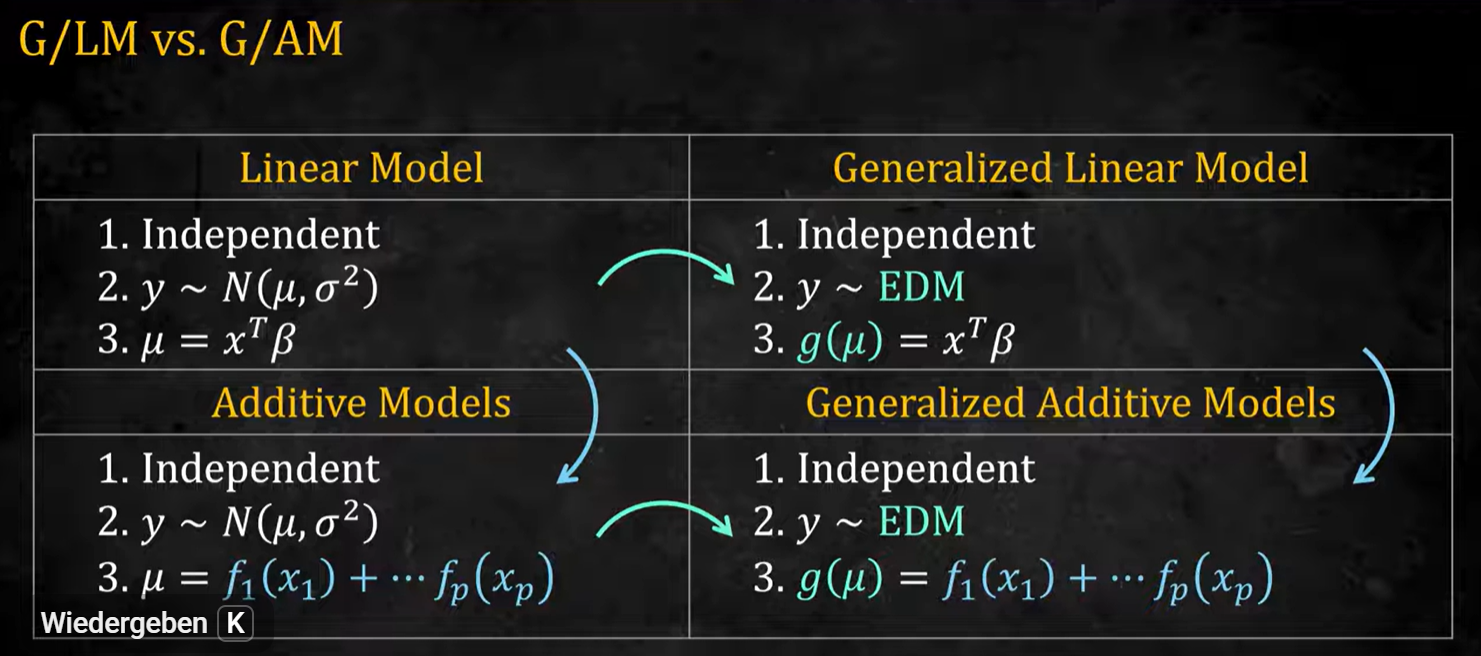
from https://www.youtube.com/watch?v=wVGvhT151lg 